# NILM — UK-DALE House 1 : préparation des données & data mining

Pipeline de préparation pour la désagrégation de charge (seq2point à venir).
Cible principale : **fridge** (réfrigérateur). Maison 1, échantillonnage ~6 s.

Ordre logique : environnement → config → **validation des canaux** → diagnostic des trous → reconstruction sur grille honnête → segmentation → choix du seuil de longueur → concaténation traçable → statistiques descriptives.


## 0. Environnement


In [38]:
# Install NILMTK
!pip install nilmtk
!pip install git+https://github.com/nilmtk/nilm_metadata.git

ERROR: Could not find a version that satisfies the requirement nilmtk (from versions: none)
ERROR: No matching distribution found for nilmtk
  Cloning https://github.com/nilmtk/nilm_metadata.git to /tmp/pip-req-build-9jtsob73
  Running command git clone --filter=blob:none --quiet https://github.com/nilmtk/nilm_metadata.git /tmp/pip-req-build-9jtsob73
  fatal: unable to access 'https://github.com/nilmtk/nilm_metadata.git/': Could not resolve host: github.com
  error: subprocess-exited-with-error
  
  × git clone --filter=blob:none --quiet https://github.com/nilmtk/nilm_metadata.git /tmp/pip-req-build-9jtsob73 did not run successfully.
  │ exit code: 128
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× git clone --filter=blob:none --quiet https://github.com/nilmtk/nilm_metadata.git /tmp/pip-req-build-9jtsob73 did not run successfully.
│ exit code: 128
╰─> See above for output.

not

In [28]:
# Dépendances. Sur Kaggle, la plupart sont déjà présentes ; on garantit les versions.
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ("h5py", "pandas", "numpy", "scikit-learn", "matplotlib", "tqdm"):
    install(pkg)

print("✅ Dépendances installées.")

✅ Dépendances installées.


In [29]:
# Imports pour la phase préparation / data mining.
# (torch, sklearn pour le modèle seq2point seront importés au moment de la modélisation.)
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("✅ Imports OK.")

✅ Imports OK.


## 1. Configuration

Point unique de vérité pour le mapping des compteurs, les paramètres de grille et les seuils ON.

> **Note** : `fridge` pointe sur **meter 12** (et non 5). Le canal a été identifié par sa signature physique — voir §3. `dish_washer` est volontairement exclu (non utilisé).

In [30]:
# ════════════════════════════════════════════════════════════════════
#  Mapping des compteurs (UK-DALE House 1) — VALIDÉ par signature (cf. §3)
# ════════════════════════════════════════════════════════════════════
HOUSE_ID = 1
APPLIANCES = {                # nom → numéro de meter
    "kettle":          10,
    "fridge":          12,  
    "washing_machine":  6,
    "microwave":       13,
}

# ── Paramètres de reconstruction sur grille ──
GRID_FREQ    = "6s"                  # grille régulière (House 1 ≈ 6 s)
SAMPLE_PERIOD = pd.Timedelta("6s")
TOLERANCE    = pd.Timedelta("5s")    # un échantillon compte s'il tombe à < 5 s d'un point de grille
GAP_FACTOR   = 3                     # diagnostic : un "trou" = écart > 3 × période
MAX_GAP      = 9                     # trou de longueur < 10 → interpolé ; ≥ 10 → laissé vide (NaN)
MIN_WINDOW   = 301                   # fenêtre seq2point (longueur min d'un run exploitable)
MIN_LEN      = 975                   # longueur min finale d'un segment ≈ 1,6 h ≈ 3× la fenêtre (cf. §7)

# ── Seuils ON (W) — en dessous = OFF. Validés par signature (cf. §3 / §10) ──
ON_THRESHOLDS = {
    "kettle":          2000,
    "fridge":            50,
    "washing_machine":   20,
    "microwave":        200,
}

# ════════════════════════════════════════════════════════════════════
#  Localiser le .h5 sous /kaggle/input
# ════════════════════════════════════════════════════════════════════
def find_h5():
    roots = [
        "/kaggle/input/uk-dale",
        "/kaggle/input/datasets/abdelmdz/uk-dale",
        "/kaggle/input",
    ]
    for r in roots:
        if os.path.exists(r):
            hits = glob.glob(f"{r}/**/*.h5", recursive=True) + glob.glob(f"{r}/*.h5")
            if hits:
                return hits[0]
    raise FileNotFoundError("Aucun .h5 sous /kaggle/input/. Le dataset uk-dale est-il ajouté ?")

UKDALE_PATH = find_h5()
print(f"✅ HDF5 : {UKDALE_PATH}  ({os.path.getsize(UKDALE_PATH)/1e9:.2f} GB)")

# Fix plugin HDF5 sur Kaggle (sinon crash à la lecture)
os.makedirs("/usr/local/hdf5/lib/plugin", exist_ok=True)

✅ HDF5 : /kaggle/input/datasets/abdelmdz/uk-dale/ukdale.h5  (6.33 GB)


## 2. Helper de lecture

`_read_meter` extrait la série de puissance active d'un compteur, robuste au nom de colonne.

In [31]:
def _read_meter(store, building, meter):
    """Retourne la série de puissance active (float32) d'un compteur UK-DALE."""
    key = f"/building{building}/elec/meter{meter}"
    if key not in store:
        raise KeyError(key)
    d = store[key]
    for col in [("power", "active"), "power active", "active", 0]:
        if col in d.columns:
            return d[col].astype(np.float32)
    num = d.select_dtypes(include=[np.number]).columns
    if len(num):
        return d[num[0]].astype(np.float32)
    raise ValueError(f"Pas de colonne numérique dans {key}")

## 3. Validation des canaux (identification par signature)

**Garde-fou méthodologique.** Un mapping de compteur erroné contamine tout l'entraînement en silence. Avant de faire confiance au mapping, on le valide par la physique : un réfrigérateur ne tire jamais ~2 kW. On identifie chaque appareil par sa signature (puissance ON, max, duty cycle), puis on confirme visuellement sur 24 h.

C'est ainsi que `fridge` a été corrigé de meter 5 (max ~4 kW, duty 4 % → incohérent) vers **meter 12** (plateau ~90 W, duty ~42 %, cyclage régulier → signature compresseur).

In [32]:
# Table de signatures : devine l'appareil de chaque compteur par ses statistiques.
with pd.HDFStore(UKDALE_PATH, "r") as store:
    print(f"{'meter':>6} | {'P_méd_ON':>8} | {'P_max':>7} | {'duty%':>6} | indice")
    print("-" * 56)
    for ch in range(1, 25):
        try:
            x = _read_meter(store, HOUSE_ID, ch).to_numpy()
            on = x[x >= 10]
            if len(on) == 0:
                continue
            pmed, pmax, duty = np.median(on), x.max(), 100 * (x >= 10).mean()
            if   pmax < 500 and 60 < pmed < 200 and duty > 15: hint = "FRIDGE ?"      # faible P + cyclage
            elif pmax > 2000 and pmed > 1500 and duty < 1.5:   hint = "kettle"
            elif 1000 < pmed < 1700 and duty < 1.5:            hint = "microwave"
            elif pmax > 1800 and 1 < duty < 8:                 hint = "washer/dishwasher"
            else:                                              hint = ""
            print(f"{ch:>6} | {pmed:>8.0f} | {pmax:>7.0f} | {duty:>6.2f} | {hint}")
        except Exception:
            pass

 meter | P_méd_ON |   P_max |  duty% | indice
--------------------------------------------------------
     1 |      256 |    8788 | 100.00 | 
     2 |       12 |    2060 |  87.08 | 
     3 |       48 |    2048 |  19.99 | 
     4 |       19 |     974 |  70.32 | 
     5 |      188 |    3999 |   4.90 | washer/dishwasher
     6 |      121 |    3973 |   2.68 | washer/dishwasher
     7 |      103 |    3109 |  11.51 | 
     8 |      134 |    1325 |  13.66 | 
     9 |       69 |     514 |  24.91 | 
    10 |     2346 |    3948 |   0.69 | kettle
    11 |     1576 |    3627 |   0.55 | kettle
    12 |       89 |    3323 |  42.51 | 
    13 |     1525 |    3267 |   0.59 | kettle
    14 |       51 |    2787 |  42.83 | 
    15 |       13 |    3131 |   2.91 | washer/dishwasher
    16 |      558 |    3443 |   0.26 | 
    17 |       23 |    1664 |  15.54 | 
    18 |       10 |     134 |  26.94 | 
    19 |       16 |    2144 |  16.19 | 
    20 |       58 |     129 |   0.20 | 
    21 |       10 |    2058 

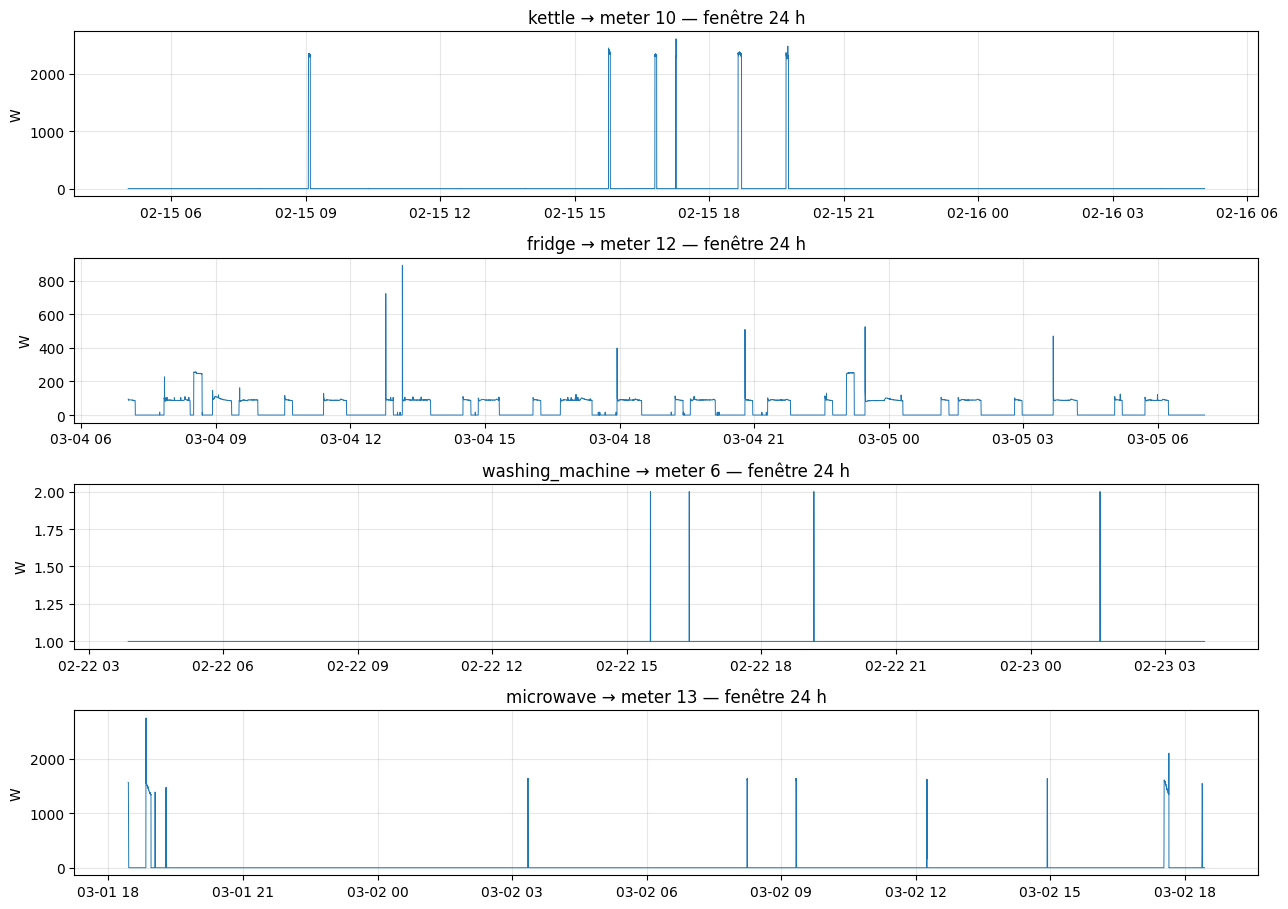

In [33]:
# Confirmation visuelle : 24 h pour chaque appareil mappé.
# Le fridge doit montrer des créneaux rectangulaires réguliers (~90 W) = compresseur.
with pd.HDFStore(UKDALE_PATH, "r") as store:
    n = len(APPLIANCES)
    fig, axes = plt.subplots(n, 1, figsize=(13, 2.3 * n))
    if n == 1:
        axes = [axes]
    for ax, (name, ch) in zip(axes, APPLIANCES.items()):
        s = _read_meter(store, HOUSE_ID, ch)
        s = s[~s.index.duplicated()].sort_index()
        mid = s.index[len(s) // 2]
        win = s.loc[mid : mid + pd.Timedelta("24h")]
        ax.plot(win.index, win.values, lw=0.7)
        ax.set_title(f"{name} → meter {ch} — fenêtre 24 h")
        ax.set_ylabel("W")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Diagnostic des trous (gaps) par compteur

Avant de reconstruire, on quantifie la couverture réelle de chaque série : nombre de trous, trou maximal, temps total manquant. Révèle les canaux trop lacunaires.

In [34]:
with pd.HDFStore(UKDALE_PATH, "r") as store:
    agg = _read_meter(store, HOUSE_ID, 1).rename("aggregate")
    agg = agg[~agg.index.duplicated(keep="first")].sort_index()
    series = {"aggregate": agg}
    for name, chan in APPLIANCES.items():
        try:
            s = _read_meter(store, HOUSE_ID, chan)
            series[name] = s[~s.index.duplicated(keep="first")].sort_index()
        except Exception as e:
            print(f"⚠️ {name}: {e}")

print(f"Agrégat : {agg.index.min()} → {agg.index.max()} | {len(agg):,} pts\n")

rows = []
for name, s in series.items():
    dt   = s.index.to_series().diff().dropna()
    gaps = dt[dt > GAP_FACTOR * SAMPLE_PERIOD]
    missing = gaps.sum() - len(gaps) * SAMPLE_PERIOD            # temps réellement perdu
    rows.append({
        "meter": name,
        "start": s.index.min(), "end": s.index.max(), "n_pts": len(s),
        "n_gaps": len(gaps),
        "gap_max_h": round(gaps.max().total_seconds() / 3600, 1) if len(gaps) else 0.0,
        "missing_h": round(missing.total_seconds() / 3600, 1),
        "clamp_avant": int((agg.index < s.index.min()).sum()),
        "clamp_apres": int((agg.index > s.index.max()).sum()),
    })
print(pd.DataFrame(rows).to_string(index=False))

Agrégat : 2012-11-09 22:28:15+00:00 → 2017-04-26 18:32:40+01:00 | 21,837,636 pts

          meter                     start                       end    n_pts  n_gaps  gap_max_h  missing_h  clamp_avant  clamp_apres
      aggregate 2012-11-09 22:28:15+00:00 2017-04-26 18:32:40+01:00 21837636   41559      273.8     1506.8            0            0
         kettle 2012-11-09 22:28:18+00:00 2017-04-26 18:32:46+01:00 18881051   57164      700.6     2637.4            1            0
         fridge 2012-12-14 22:21:32+00:00 2017-04-26 18:32:51+01:00 19381298   21006      174.1     1009.6       269526            0
washing_machine 2012-11-09 22:28:18+00:00 2017-04-26 18:35:30+01:00 19819392    2549      219.0     1194.3            1            0
      microwave 2012-12-14 22:21:33+00:00 2017-04-26 18:33:03+01:00 19406625   19824      174.1      982.2       269526            0


## 5. Reconstruction sur grille régulière (`df_h`)

On reprojette toutes les séries sur une grille régulière à 6 s. **NaN = vrai trou** (aucune valeur réelle à < 5 s). Les trous courts (< 10 pas) sont interpolés linéairement ; les trous longs restent NaN pour ne pas inventer de données.

In [35]:
# ── 5a. Reprojection sur grille régulière ──
t_read = t_reindex = 0.0
t0 = time.perf_counter()

with pd.HDFStore(UKDALE_PATH, "r") as store:
    t = time.perf_counter()
    agg = _read_meter(store, HOUSE_ID, 1).rename("aggregate")
    agg = agg[~agg.index.duplicated(keep="first")].sort_index()
    t_read += time.perf_counter() - t

    grid = pd.date_range(agg.index.min(), agg.index.max(), freq=GRID_FREQ, tz=agg.index.tz)

    t = time.perf_counter()
    cols = {"aggregate": agg.reindex(grid, method="nearest", tolerance=TOLERANCE)}
    t_reindex += time.perf_counter() - t

    for name, chan in APPLIANCES.items():
        try:
            t = time.perf_counter()
            s = _read_meter(store, HOUSE_ID, chan)
            s = s[~s.index.duplicated(keep="first")].sort_index()
            t_read += time.perf_counter() - t

            t = time.perf_counter()
            cols[name] = s.reindex(grid, method="nearest", tolerance=TOLERANCE)
            t_reindex += time.perf_counter() - t
        except Exception as e:
            print(f"⚠️ {name}: {e}")

df_h = pd.DataFrame(cols).astype("float32")
print(f"  ↳ lecture HDF5 : {t_read:.1f}s | reindex : {t_reindex:.1f}s | total : {time.perf_counter()-t0:.1f}s")
print(f"Grille : {len(df_h):,} pts @ {GRID_FREQ}  ({df_h.index.min()} → {df_h.index.max()})")

KeyboardInterrupt: 

In [ ]:
# ── 5b. Interpolation des trous courts (< MAX_GAP+1), longs laissés en NaN ──
def fill_short_gaps(s, max_gap=MAX_GAP):
    isna = s.isna().to_numpy()
    if not isna.any():
        return s
    filled = s.interpolate(method="linear", limit_area="inside").to_numpy()
    d = np.diff(np.concatenate(([0], isna.view(np.int8), [0])))
    starts, ends = np.where(d == 1)[0], np.where(d == -1)[0]
    mask = (ends - starts) > max_gap          # runs ≥ max_gap+1 → on remet NaN
    for st, en in zip(starts[mask], ends[mask]):
        filled[st:en] = np.nan
    return pd.Series(filled, index=s.index, dtype="float32")

t = time.perf_counter()
for c in df_h.columns:
    df_h[c] = fill_short_gaps(df_h[c])
print(f"  ↳ interpolation trous courts : {time.perf_counter()-t:.1f}s")

print("\nNaN restants par colonne (après interp courte) :")
print((df_h.isna().mean() * 100).round(2).astype(str).add(" %").to_string())

## 6. Découpe en segments contigus valides

Un segment = un run où **toutes** les colonnes sont simultanément valides (aucun NaN). On ne conserve d'abord que les runs ≥ `MIN_WINDOW` (301), seuil sous lequel aucune fenêtre seq2point n'est possible. Le filtrage final (plus strict) vient en §8, justifié par l'analyse de couverture.

In [ ]:
# Colonnes exigées (toutes — plus de dish_washer à exclure)
cols_req = list(df_h.columns)
valid = df_h[cols_req].notna().all(axis=1).to_numpy()

# Runs contigus valides
d = np.diff(np.concatenate(([0], valid.view(np.int8), [0])))
seg_starts, seg_ends = np.where(d == 1)[0], np.where(d == -1)[0]

sub = df_h[cols_req]                                # sélection UNE seule fois (hors boucle !)
segments_all = [sub.iloc[st:en].copy()
                for st, en in zip(seg_starts, seg_ends)
                if en - st >= MIN_WINDOW]           # filtre AVANT recopie
print(f"{len(seg_starts):,} runs valides → {len(segments_all):,} segments ≥ {MIN_WINDOW} pts")

# Métadonnées (base pour l'analyse de couverture)
meta_all = pd.DataFrame({
    "start": [s.index[0]  for s in segments_all],
    "end":   [s.index[-1] for s in segments_all],
    "n":     [len(s)      for s in segments_all],
})
meta_all["duree_h"] = (meta_all["end"] - meta_all["start"]).dt.total_seconds() / 3600
print(f"Longueurs (pts) : min={meta_all.n.min()}  méd={int(meta_all.n.median())}  "
      f"max={meta_all.n.max():,}  total={meta_all.n.sum():,}")

## 7. Couverture & choix de `MIN_LEN`

Les données ne sont pas concentrées dans quelques méga-blocs : pas de « falaise » nette. On analyse où vit réellement la donnée, en **temps** puis en **fenêtres seq2point** (métrique honnête : un segment de $n$ points fournit $n-300$ fenêtres, donc les courts segments sont doublement pénalisés).

In [ ]:
dur_h = meta_all["duree_h"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Histogramme à bins log
ax = axes[0]
bins = np.logspace(np.log10(dur_h.min()), np.log10(dur_h.max()), 40)
ax.hist(dur_h, bins=bins, color="#4C72B0", edgecolor="white", linewidth=0.4)
ax.set_xscale("log")
ax.set_xlabel("Durée du segment (h, échelle log)")
ax.set_ylabel("Nombre de segments")
ax.set_title("Distribution des durées de segments")
ax.axvline(MIN_WINDOW * 6 / 3600, color="crimson", ls="--", lw=1, label=f"seuil {MIN_WINDOW} pts")
ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=8)

# (b) Couverture cumulée (en temps)
ax = axes[1]
order = np.argsort(dur_h)[::-1]
cum_frac = np.cumsum(dur_h[order]) / dur_h.sum()
ax.plot(np.arange(1, len(cum_frac) + 1), cum_frac * 100, color="#55A868", lw=1.8)
k90 = np.searchsorted(cum_frac, 0.90) + 1
ax.axhline(90, color="grey", ls=":", lw=1)
ax.axvline(k90, color="crimson", ls="--", lw=1, label=f"90 % en {k90} segments")
ax.set_xlabel("Nb de segments (triés du plus long au plus court)")
ax.set_ylabel("% du temps exploitable cumulé")
ax.set_title("Couverture cumulée")
ax.set_ylim(0, 101)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Médiane : {np.median(dur_h):.2f} h | moyenne : {dur_h.mean():.2f} h | max : {dur_h.max():.1f} h")

In [ ]:
# Couverture par seuil, en TEMPS puis en FENÊTRES seq2point.
n_pts = meta_all["n"].to_numpy()
n_win = np.maximum(n_pts - (MIN_WINDOW - 1), 0)        # fenêtres exploitables par segment

dur_sorted = np.sort(dur_h)[::-1]
cum_t = np.cumsum(dur_sorted) / dur_h.sum()
pts_sorted = np.sort(n_pts)[::-1]
cum_w = np.cumsum(np.sort(n_win)[::-1]) / n_win.sum()

print("─ En temps ─")
for seuil in (0.90, 0.95, 0.99):
    k = np.searchsorted(cum_t, seuil) + 1
    print(f"  {seuil:.0%} → {k:>4} segments (durée min : {dur_sorted[k-1]:.2f} h)")

print("─ En fenêtres seq2point ─")
for seuil in (0.90, 0.95, 0.99):
    k = np.searchsorted(cum_w, seuil) + 1
    print(f"  {seuil:.0%} → {k:>4} segments (taille min : {pts_sorted[k-1]} pts = {pts_sorted[k-1]*6/3600:.2f} h)")

## 8. Filtrage final des segments (`MIN_LEN = 975`)

Seuil retenu : **975 points (~1,6 h, ~3× la fenêtre)**. Élimine ~37 % des segments (la traîne basse) tout en préservant ~99 % des fenêtres d'entraînement. Bonus : garantit assez de fenêtres à contexte temporel complet par segment, limitant les effets de bord.

In [ ]:
# Filtrage par longueur (réutilise segments_all, pas de re-slicing de df_h)
segments = [s for s in segments_all if len(s) >= MIN_LEN]

meta = pd.DataFrame({
    "start": [s.index[0]  for s in segments],
    "end":   [s.index[-1] for s in segments],
    "n":     [len(s)      for s in segments],
})
meta["duree_h"] = (meta["end"] - meta["start"]).dt.total_seconds() / 3600
n_win = (meta["n"] - (MIN_WINDOW - 1)).clip(lower=0)
span_d = (df_h.index[-1] - df_h.index[0]).total_seconds() / 86400

print(f"📦 {len(segments)} segments retenus (≥ {MIN_LEN} pts).")
print(f"   Points totaux      : {meta.n.sum():,}")
print(f"   Fenêtres seq2point : {n_win.sum():,}")
print(f"   Durée couverte     : {meta.duree_h.sum()/24:.1f} j "
      f"({meta.duree_h.sum()/24/span_d*100:.1f} % de la période)")
print(f"   Longueurs (pts)    : min={meta.n.min()}  méd={int(meta.n.median())}  max={meta.n.max():,}")
print("\n15 plus longs segments :")
print(meta.sort_values("n", ascending=False).head(15).to_string(index=False))

## 9. Concaténation traçable (`df_all`)

On regroupe les segments en un seul DataFrame, **en gardant un `segment_id`**. Indispensable : il permettra de n'autoriser une fenêtre seq2point que si ses 301 points partagent le même `segment_id`, évitant qu'une fenêtre enjambe une frontière (gap de plusieurs heures).

In [ ]:
df_all = pd.concat([seg.assign(segment_id=i) for i, seg in enumerate(segments)])
df_all = df_all.sort_index()
df_all["segment_id"] = df_all["segment_id"].astype("int32")

print(f"df_all : {len(df_all):,} lignes × {df_all.shape[1]} colonnes")
print(f"   {df_all['segment_id'].nunique():,} segments")
print(f"   index monotone croissant : {df_all.index.is_monotonic_increasing}")
print(f"   doublons d'index         : {df_all.index.duplicated().sum()}")
print(df_all.head())

## 10. Statistiques descriptives

Sur des données de puissance, `describe()` brut est **trompeur** (mélange OFF≈0 et ON). La lecture honnête sépare le marginal (tout confondu) du conditionnel (sachant ON). On vérifie d'abord que les seuils ON coupent bien dans le creux entre OFF et ON.

In [ ]:
# Vérification des seuils ON : p5 (puissance ON) doit être nettement > seuil (= on coupe dans le creux)
print("Vérification des seuils ON (sur df_all) :")
for c, thr in ON_THRESHOLDS.items():
    x = df_all[c].to_numpy()
    on = x[x >= thr]
    print(f"  {c:16s} seuil={thr:>4} W | duty={100*(x>=thr).mean():5.2f}% | "
          f"P_ON: méd={np.median(on):.0f} p5={np.percentile(on,5):.0f} p95={np.percentile(on,95):.0f} W")

In [ ]:
app_cols = [c for c in df_all.columns if c not in ("aggregate", "segment_id")]
DT_H = 6 / 3600

# (1) describe() marginal — contre-exemple : médiane/quartiles ≈ 0 pour les appareils rares
print("═══ describe() marginal (TROMPEUR pour la puissance) ═══")
print(df_all[["aggregate"] + app_cols].describe(percentiles=[.5, .9, .99]).T.round(1).to_string())

# (2) Table descriptive honnête (marginal + conditionnel ON)
agg_energy = df_all["aggregate"].sum() * DT_H / 1000          # kWh
rows = []
for c in app_cols:
    x = df_all[c].to_numpy()
    on = x >= ON_THRESHOLDS[c]
    energy = x.sum() * DT_H / 1000
    rows.append({
        "appareil": c,
        "duty_%":         100 * on.mean(),
        "P_ON_méd":       np.median(x[on]) if on.any() else np.nan,
        "P_ON_p95":       np.percentile(x[on], 95) if on.any() else np.nan,
        "P_max":          x.max(),
        "énergie_kWh":    energy,
        "part_énergie_%": 100 * energy / agg_energy,
        "skew":           pd.Series(x).skew(),
    })
print("\n═══ Stats descriptives HONNÊTES (marginal + conditionnel ON) ═══")
print(pd.DataFrame(rows).set_index("appareil").round(2).to_string())

# (3) Bilan de couverture énergétique
sum_app = sum(df_all[c].sum() for c in app_cols) * DT_H / 1000
print(f"\nÉnergie agrégat total   : {agg_energy:,.0f} kWh")
print(f"Somme appareils mesurés : {sum_app:,.0f} kWh "
      f"({100*sum_app/agg_energy:.1f} % de l'agrégat → reste = appareils non mesurés)")